In [1]:
# import packages to read geopackages fast
import dask
import geopandas as gpd
import pandas as pd
# dask client
from dask.distributed import Client
import numpy as np

In [2]:
# read the first geopackage D:/waterkering.gpkg

waterkering = gpd.read_file("waterkering.gpkg", layer="waterkering")

<Axes: >

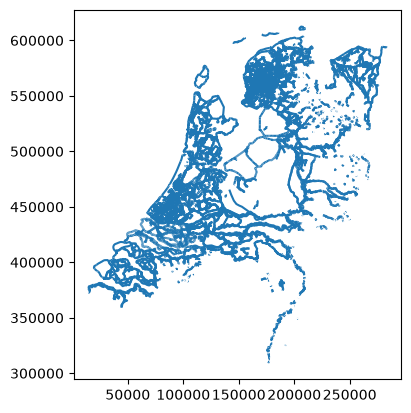

In [3]:
# plot the geopackage
waterkering.plot()

In [4]:
# download the brocpt geopackage from https://service.pdok.nl/tno/bro-geotechnischsondeeronderzoek/atom/downloads/brocptvolledigeset_v2_0.zip
import requests
import zipfile
import io

url = "https://service.pdok.nl/tno/bro-geotechnischsondeeronderzoek/atom/downloads/brocptvolledigeset_v2_0.zip"

response = requests.get(url)
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall("brocpt")

In [5]:
# read the geopackage with dask D:/brocptvolledigeset_v2_0.gpkg layer geotechinical_cpt_survey
geotechnical_cpt_survey = gpd.read_file("brocpt/brocptvolledigeset_v2_0.gpkg", layer="geotechnical_cpt_survey")
# print the first 5 rows of the geopackage
print(geotechnical_cpt_survey.head())


            bro_id quality_regime delivery_accountable_party  \
0  CPT000000000001        IMBRO/A                   50200097   
1  CPT000000000002        IMBRO/A                   50200097   
2  CPT000000000003        IMBRO/A                   50200097   
3  CPT000000000004        IMBRO/A                   50200097   
4  CPT000000000005        IMBRO/A                   50200097   

    delivery_context survey_purpose research_report_date cpt_standard  \
0  archiefoverdracht       onbekend           2007-09-07      NEN5140   
1  archiefoverdracht       onbekend           2007-09-07      NEN5140   
2  archiefoverdracht       onbekend           2015-02-27   ISO22476D1   
3  archiefoverdracht       onbekend           2015-02-27   ISO22476D1   
4  archiefoverdracht       onbekend           2015-02-27   ISO22476D1   

  additional_investigation_performed   applied_transformation  \
0                           onbekend  7parameterTransformatie   
1                           onbekend  7paramet

In [6]:
# change the crs to 28992 from 4326
geotechnical_cpt_survey = geotechnical_cpt_survey.to_crs(epsg=28992)

<Axes: >

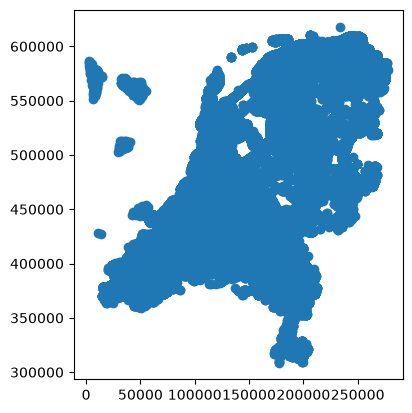

In [7]:
# plot the points
geotechnical_cpt_survey.plot()

<Axes: >

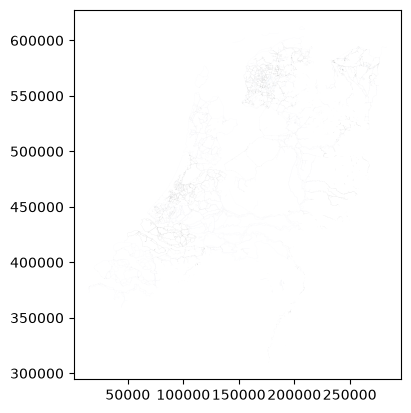

In [8]:
# buffer the waterkering with 2 meters
waterkering_buffer = waterkering.buffer(2)
# to geodataframe
waterkering_buffer = gpd.GeoDataFrame(geometry=waterkering_buffer, crs=waterkering.crs)
# plot the buffer
waterkering_buffer.plot()

<Axes: >

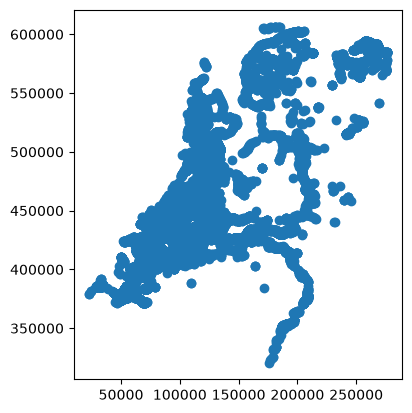

In [9]:
# find the intersections between the buffer and the points
intersections = gpd.overlay(geotechnical_cpt_survey, waterkering_buffer, how='intersection')
# plot the intersections
intersections.plot()

In [ ]:
# get all bro ids from the intersections in a list
bro_ids = intersections['bro_id'].unique().tolist()
bro_ids = bro_ids[:10]

In [11]:
import requests
import json
import os
import xml.dom.minidom as minidom
from pathlib import Path
from geolib_plus.bro_xml_cpt import BroXmlCpt
from pathlib import Path
from geolib_plus.robertson_cpt_interpretation import RobertsonCptInterpretation
from geolib_plus.robertson_cpt_interpretation import UnitWeightMethod
from geolib_plus.robertson_cpt_interpretation import OCRMethod
from geolib_plus.robertson_cpt_interpretation import ShearWaveVelocityMethod

def read_and_process(c):
    output_dir = "cpts/"
    interpret_cpt = True
    # print(f"{i} of {len(cpt_ID)}")
    cpt = requests.get(f"https://publiek.broservices.nl/sr/cpt/v1/objects/{c}")
    try:
        xml = minidom.parseString(cpt.content)
    except:
        return None

    try:
        xml.writexml(open(os.path.join(output_dir ,c + ".xml"), 'w'),
                 indent="  ",
                 addindent="  ",
                 newl='\n',
                 encoding='UTF-8',
                 )
        xml.unlink()
        cpt_file_xml = Path(f"{os.path.join(output_dir, c+'.xml')}")
        cpt_xml = BroXmlCpt()
        cpt_xml.read(cpt_file_xml)
        if cpt_xml.coordinates == None:
            return None
        if interpret_cpt:
            cpt_xml.pre_process_data()
            # do pre-processing
            interpreter = RobertsonCptInterpretation()
            interpreter.unitweightmethod = UnitWeightMethod.LENGKEEK
            interpreter.shearwavevelocitymethod = ShearWaveVelocityMethod.ZANG
            interpreter.ocrmethod = OCRMethod.MAYNE
            cpt_xml.interpret_cpt(interpreter)
        return cpt_xml
        #out_file = open(os.path.join(output_dir ,c + ".json"), "w")
        #cpt_dict = dict(cpt_xml)
        #for k, v in cpt_dict.items():
        #    if "array" in str(type(v)):
        #        cpt_dict[k] = v.tolist()
        #    if "numpy.float32" in str(type(v)) or "numpy.float64" in str(type(v)):
        #        cpt_dict[k] = float(v)
        #cpt_dict.pop("plot_settings")
        #json.dump(cpt_dict, out_file, indent=2)
    except ValueError:
        xml.unlink()
        return None
    except UnboundLocalError:
        xml.unlink()
        return None
    except:
        print(f"Error in {c}")
        xml.unlink()
        return None
     


In [12]:
def get_interface(cpt):
    if cpt is None:
        return 0, None, None
    # fail safe check if index is empty
    litho = np.array([int(sub) for sub in cpt.lithology])
    depth = np.array(cpt.depth)
    index = np.where(litho < 6)
    if len(index[0]) == 0:
        index = 0
    else:
        index = index[0][0]
    # get the depth of the first value that is less than 6
    depth = depth[index]
    return depth, cpt.name, cpt.coordinates

In [13]:
client = Client(n_workers=14, threads_per_worker=1, memory_limit='2GB')
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 14
Total threads: 14,Total memory: 26.08 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:60947,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:61064,Total threads: 1
Dashboard: http://127.0.0.1:61068/status,Memory: 1.86 GiB
Nanny: tcp://127.0.0.1:60950,


In [ ]:
# process the cpt files in parallel using dask
cpt_ID = bro_ids
# run first the preprocessing of the cpt files and then the get interface function first delayed and then compute the results
cpts = [dask.delayed(read_and_process)(c) for c in cpt_ID]
# now the interface function is delayed and we can compute the results
cpt_interfaces = [dask.delayed(get_interface)(c) for c in cpts]
# compute the results
cpt_interfaces = dask.compute(cpt_interfaces)


In [ ]:
# save the results to a pickle file
import pickle

with open("cpt_interfaces.pkl", "wb") as f:
    pickle.dump(cpt_interfaces, f)


In [ ]:
# load the results from the pickle file
with open("cpt_interfaces.pkl", "rb") as f:
    cpt_interfaces = pickle.load(f)

In [ ]:
# first transpose the data to get the depth, name and coordinates in the right format
cpt_interfaces = cpt_interfaces[0]
depth = [c[0] for c in cpt_interfaces]
name = [c[1] for c in cpt_interfaces]
x = [c[2][0] if c[2] is not None else None for c in cpt_interfaces]
y = [c[2][1] if c[2] is not None else None for c in cpt_interfaces]
# to geodataframe
pandas_df = pd.DataFrame({"depth": depth, "name": name, "x": x, "y": y})
# to geodataframe
gdf = gpd.GeoDataFrame(pandas_df, geometry=gpd.points_from_xy(pandas_df.x, pandas_df.y))
# set the crs to 28992
gdf.crs = "EPSG:28992"
# save the geodataframe to a geopackage
gdf.to_file("cpt_interfaces.gpkg", layer="cpt_interfaces", driver="GPKG")
